# Hyperparameter Analysis: Memory & Q-Learning Parameters vs Score

This notebook analyzes the impact of Q-Learning hyperparameters (Learning Rate, Discount Factor, Epsilon, Memory Length) on agent performance across different noise levels.

In [22]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from experiments import result_utils

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [23]:
# Configuration
dir_agent_map = {
    "qlearning": "Jax QLearner"
}

results_dir = Path("../../../results/hyperparameters")

In [24]:
# Load data
print("Loading hyperparameter results...")
results_by_noise = result_utils.analyze_best_agents_per_noise(results_dir, dir_agent_map)

# Combine all results into a single DataFrame
all_results = []
for noise_level, df in results_by_noise.items():
    df_copy = df.copy()
    df_copy['Noise Level'] = noise_level
    all_results.append(df_copy)

combined_df = pd.concat(all_results, ignore_index=True)
print(f"Loaded {len(combined_df)} records across {len(results_by_noise)} noise levels.")
combined_df.head()

Loading hyperparameter results...
Loaded 318 records across 3 noise levels.


,Agent Type,Hyperparameters,Mean Score,Num Repetitions,Noise Level
0,Jax QLearner,QLearner_0.9_0.9_0.1_1_0.999,2747.100000,5,0.0
1,Jax QLearner,QLearner_0.9_0.5_0.1_2_0.999,2694.127273,5,0.0
2,Jax QLearner,QLearner_0.5_0.5_0.1_1_0.999,2662.227273,5,0.0
3,Jax QLearner,QLearner_0.5_0.5_0.1_2_0.999,2598.900000,5,0.0
4,Jax QLearner,QLearner_0.9_0.5_0.1_1_0.999,2588.918182,5,0.0


In [25]:
# Parse Hyperparameters
# Format: QLearner_{lr}_{gamma}_{epsilon}_{mem}

def parse_hyperparams(row):
    params = row['Hyperparameters'].split('_')
    # params[0] is 'QLearner'
    return pd.Series({
        'Learning Rate': float(params[1]),
        'Discount Factor': float(params[2]),
        'Epsilon': float(params[3]),
        'Memory Length': int(params[4]),
        'Decay Rate': float(params[5])
    })

hyperparam_df = combined_df.apply(parse_hyperparams, axis=1)
final_df = pd.concat([combined_df, hyperparam_df], axis=1)
final_df.head()

,Agent Type,Hyperparameters,Mean Score,Num Repetitions,Noise Level,Learning Rate,Discount Factor,Epsilon,Memory Length,Decay Rate
0,Jax QLearner,QLearner_0.9_0.9_0.1_1_0.999,2747.100000,5,0.0,0.9,0.9,0.1,1.0,0.999
1,Jax QLearner,QLearner_0.9_0.5_0.1_2_0.999,2694.127273,5,0.0,0.9,0.5,0.1,2.0,0.999
2,Jax QLearner,QLearner_0.5_0.5_0.1_1_0.999,2662.227273,5,0.0,0.5,0.5,0.1,1.0,0.999
3,Jax QLearner,QLearner_0.5_0.5_0.1_2_0.999,2598.900000,5,0.0,0.5,0.5,0.1,2.0,0.999
4,Jax QLearner,QLearner_0.9_0.5_0.1_1_0.999,2588.918182,5,0.0,0.9,0.5,0.1,1.0,0.999


In [26]:
# Visualization Function
def plot_param_impact(df, param_name, score_col='Mean Score', noise_col='Noise Level'):
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=df,
        x=param_name,
        y=score_col,
        hue=noise_col,
        marker='o',
        palette='viridis',
        err_style='bars', # Show error bars if there are multiple points
        errorbar=('ci', 95)
    )
    plt.title(f'Impact of {param_name} on Score across Noise Levels')
    plt.xlabel(param_name)
    plt.ylabel('Mean Score')
    plt.legend(title='Noise Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

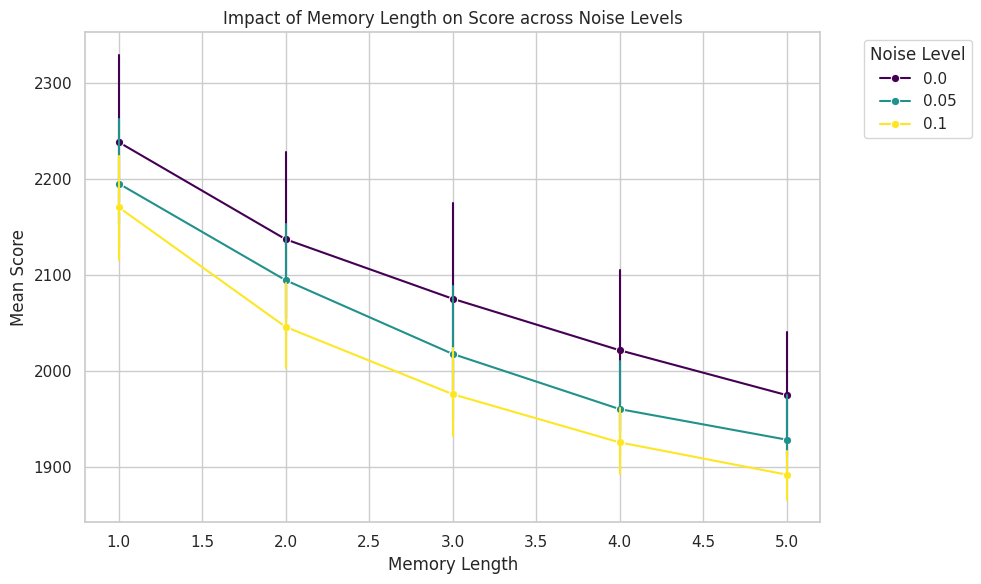

In [27]:
# 1. Impact of Memory Length
plot_param_impact(final_df, 'Memory Length')

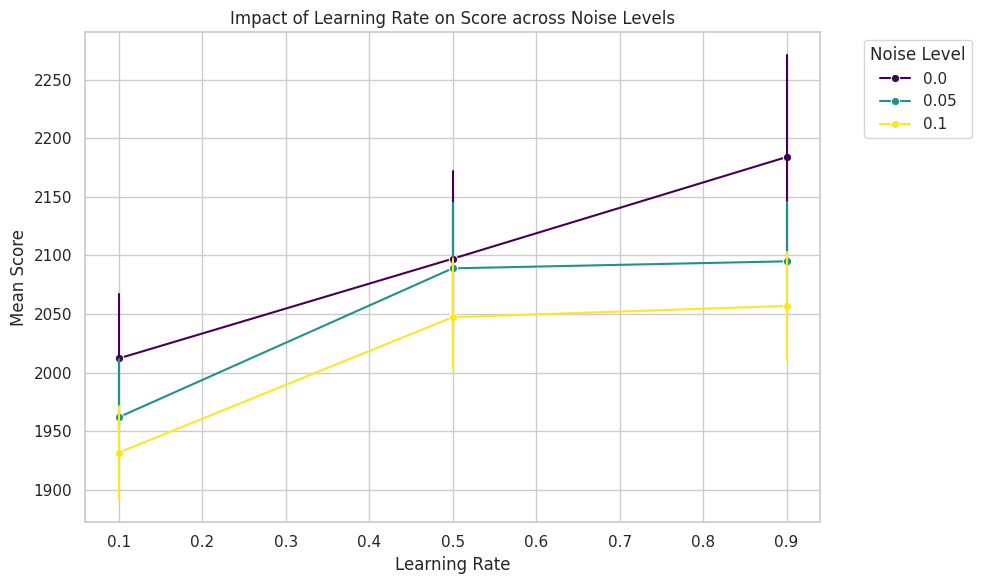

In [28]:
# 2. Impact of Learning Rate
plot_param_impact(final_df, 'Learning Rate')

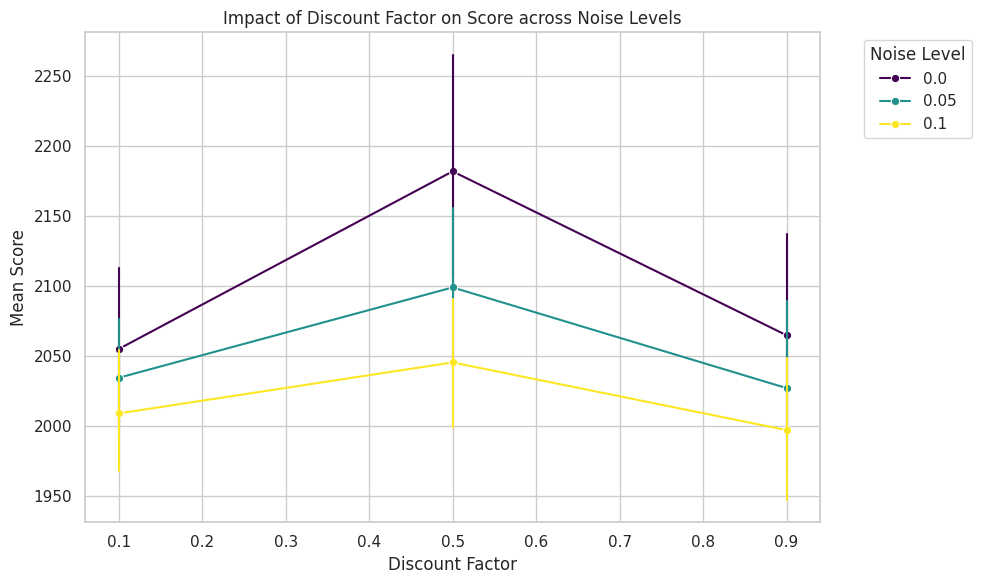

In [29]:
# 3. Impact of Discount Factor
plot_param_impact(final_df, 'Discount Factor')

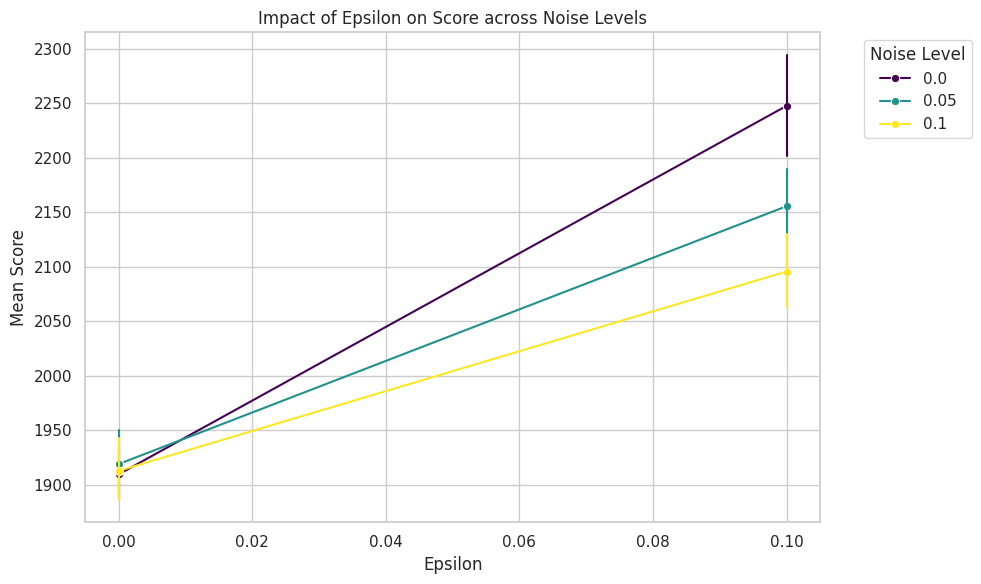

In [30]:
# 4. Impact of Epsilon
plot_param_impact(final_df, 'Epsilon')

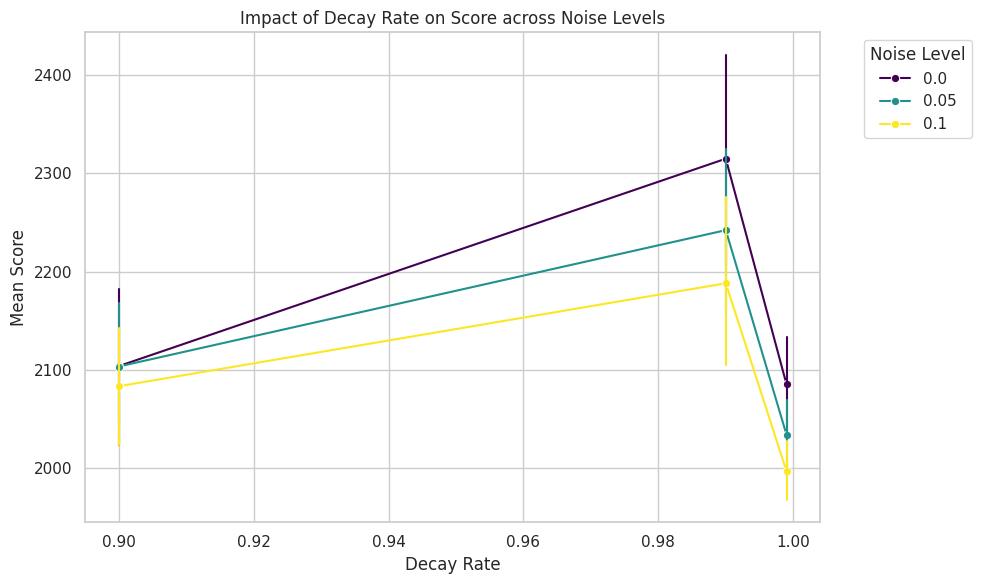

In [32]:
# 5. Impact of Decay
plot_param_impact(final_df, 'Decay Rate')